# Discharge

*[CEGM1000 MUDE](http://mude.citg.tudelft.nl/)*

*Written by: Anna Störiko, Ronald Brinkgreve*

*Due: Wednesday, September 9, 2026.*

# Part 1: Discharge Estimation and Numerical Integration

## Discharge Estimation by Dilution Gauging

In many hydrological and engineering applications, it is important to know how much water flows through a river or stream.
A simple method to estimate the discharge in small rivers and streams is so called dilution gauging.
In this method, a known amount of salt is added to the river and the concentration of the salt is measured downstream.

![](https://files.mude.citg.tudelft.nl/dilution_gauging.svg)

Based on a mass balance, the discharge $Q$ [$\mathrm{L}^3 \mathrm{T}^{-1}$] can then be estimated from the injected mass $m [\mathrm{M}]$ and the area under the concentration curve $A$:

$$Q = \cfrac{m}{A} = \cfrac{m}{\int_0^{t_{\text{end}}} c(t) dt}$$

where $c(t) [\mathrm{M} \mathrm{L}^{-3}]$ is the concentration of salt in the river above the baseline level at time $t$ and $t_{\text{end}}$ is the end time of the measurement, well after the concentration returned to its baseline value.

The plot below shows such a concentration curve. In this assignment, you will determine the discharge based on this curve.
To evaluate the integral under the curve from the discrete measurements, you will have to use numerical integration techniques.

Text(0.5, 0, 'Time [s]')

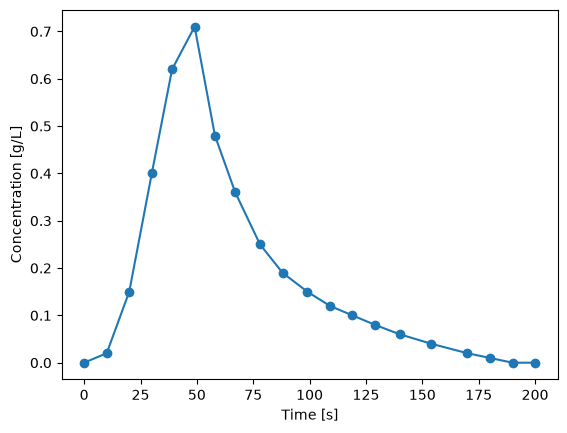

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# time in seconds
time = np.array([  0.,  10.,  20.,  30.,  39.,  49.,  58.,  67.,  78.,  88., 99.,
       109., 119., 129., 140., 154., 170., 180., 190., 200.])
# concentrations in g/L
concentration = np.array([0, 0.02, 0.15, 0.4, 0.62, 0.71, 0.48, 0.36, 0.25,
        0.19, 0.15, 0.12, 0.1, 0.08, 0.06, 0.04, 0.02, 0.01, 0, 0])
plt.plot(time, concentration, marker="o")
plt.ylabel("Concentration [g/L]")
plt.xlabel("Time [s]")

## Numerical Integration of the Concentration Curve


>
>**Task 1.1**
>
>Compute the area under the concentration curve by numerical integration. Compare two numerical integration methods of your choice. Use the `time` and `concentration` arrays from the cell above.
>

In [2]:
import numpy as np
from scipy.integrate import trapezoid

# Method 1: Trapezoidal rule
area_trapz = trapezoid(concentration, time)

# Method 2: Forward 
dt = np.diff(time)
area_forward = np.sum(concentration[:-1] * dt)

# Method 3: Backward 
area_backward = np.sum(concentration[1:] * dt)

print("Total area under the concentration curve:")
print(f"<Trapezoidal>: {area_trapz:.2f} g/L s")
print(f"<Forward sum>: {area_forward:.2f} g/L s")
print(f"<Backward sum>: {area_backward:.2f} g/L s")



Total area under the concentration curve:
<Trapezoidal>: 37.00 g/L s
<Forward sum>: 37.12 g/L s
<Backward sum>: 36.88 g/L s


>
>**Task 1.2**
>
>Which integration method is best suited for this dataset? Why?


The trapezoidal method works best for this data because it connects each pair of points with a straight line, which follows the curve's shape more closely than a flat rectangle. The forward and backward sums tend to overshoot on one side of the peak and undershoot on the other, since they assume the value stays constant across each step. Trapezoidal integration balances out these errors, making it the more accurate and simple choice for a smooth, peaked curve like this one.

>
>**Task 1.3**
>
>Compute the discharge based on the concentration data. The amount of salt used in the tracer test is 1 kg.
>

In [5]:
# Injected mass of salt
mass = 1000  # g 

# Area under the curve using trapezoidal integration
A = area_trapz  # g/L · s

# Discharge
Q = mass / A  # L/s

print(f"Discharge Q = {Q:.2f} L/s")


Discharge Q = 27.03 L/s


## Comparison of simulated and measured concentrations

To model the concentration curve, we fitted an analytical solution of the advection-dispersion-equation to the concentration data.
As a consistency if the model is a good approximation to the data, we want to compare the area under the simulated concentration curve to the area under the curve obtained with measurements.

Fitting models to data by parameter estimation will be a topic in later weeks of MUDE. For now, you do not need to understand how it works and do not need to modify the code on the cell below.

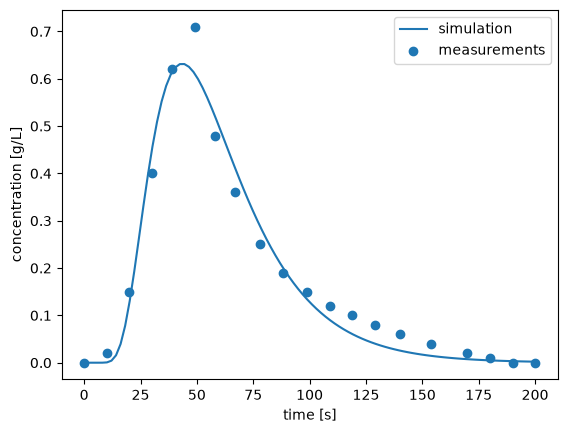

In [6]:
# You do not need to change anything in this cell

def advection_dispersion(t, x, v, D, m, A):
    """Compute the solution to the advection-dispersion equation"""
    def scalar(tt):
        """Piecewise definition for a single time point"""
        # For t=0, return the initial value
        if tt <= 0:
            return 0.0
        # Otherwise, compute the anaytical solution
        return (
            m / (A * v)
            * x / (np.sqrt(4 * np.pi * D * tt**3))
            * np.exp(-((x - v * tt) ** 2) / (4 * D * tt))
        ) / 1000 # convert from g/m³ to g/L

    f = np.vectorize(scalar, otypes=[float])
    return f(t)


# Fit the model to the data to obtain the parameters v, D and A
x = 20  # m
f = lambda time, v, D, A: advection_dispersion(time, x, v, D, mass, A)
popt, pcov = curve_fit(
    f, xdata=time, ydata=concentration, p0=(0.2, 1, 0.5), bounds=(0, np.inf)
)
v, D, area = popt  # units: m/s, m²/s, m²

# Plot the fitted curve along with the data
time_grid = np.linspace(0, time[-1], 100)
c_analytical = advection_dispersion(time_grid, x, v, D, mass, area)
plt.plot(time_grid, c_analytical, label="simulation")
plt.scatter(time, concentration, label="measurements")
plt.xlabel("time [s]")
plt.ylabel("concentration [g/L]")
plt.legend()

>
>**Task 1.4**
>
>Evaluate the integral of the simulated concentration curve from time 0 to 200 seconds, using Simpson's rule.
>
>Vary the number of integration intervals from 2 to 50. Why does the number of integration intervals have to be an even number?
>
>Observe how the result changes with different numbers of integration intervals.

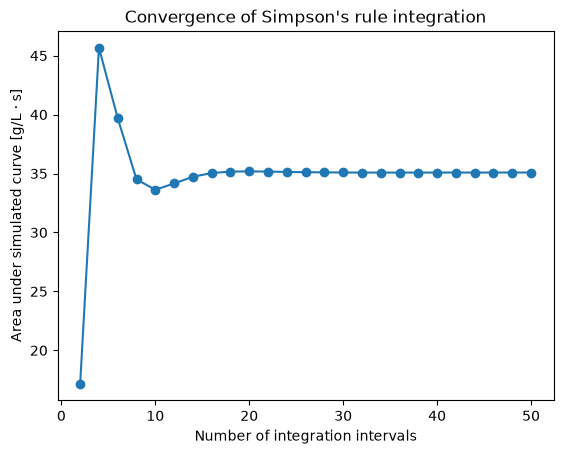

Area with 2 intervals:  17.1696 g/L s
Area with 50 intervals: 35.0848 g/L s


In [7]:
from scipy.integrate import simpson

# Vary the number of integration intervals from 2 to 50 (even numbers only)
n_intervals = np.arange(2, 51, 2)
areas_simpson = []

for n in n_intervals:
    # n intervals requires n+1 points
    t_grid = np.linspace(0, 200, n + 1)
    c_grid = advection_dispersion(t_grid, x, v, D, mass, area)
    A_simpson = simpson(c_grid, t_grid)
    areas_simpson.append(A_simpson)

areas_simpson = np.array(areas_simpson)

# Plot how the result converges as the number of intervals increases
plt.figure()
plt.plot(n_intervals, areas_simpson, marker="o")
plt.xlabel("Number of integration intervals")
plt.ylabel("Area under simulated curve [g/L · s]")
plt.title("Convergence of Simpson's rule integration")
plt.show()

print(f"Area with 2 intervals:  {areas_simpson[0]:.4f} g/L s")
print(f"Area with 50 intervals: {areas_simpson[-1]:.4f} g/L s")



>
>**Task 1.5**
>
>Compare the integral of the simulated concentrations with the integral of the measurements. Are the areas approximately the same? Comment on the accuracy of both.

In [9]:
# Area under measured concentration curve (from Task 1.1, trapezoidal)
A_measured = area_trapz

# Area under simulated concentration curve (from Task 1.4, Simpson's, finest resolution)
A_simulated = areas_simpson[-1]

# Relative difference
rel_diff = abs(A_measured - A_simulated) / A_measured * 100

print(f"Area under measured curve:  {A_measured:.4f} g/L s")
print(f"Area under simulated curve: {A_simulated:.4f} g/L s")
print(f"Relative difference: {rel_diff:.2f}%")

Area under measured curve:  37.0000 g/L s
Area under simulated curve: 35.0848 g/L s
Relative difference: 5.18%


The two areas are close but not identical — the simulated curve gives a slightly smaller area than the measured data. This makes sense: the fitted model is a smooth analytical curve, so it can't capture the higher, sharper peak seen in the raw measurements around t=50s (visible in the plot, where the model curve sits noticeably below the highest data point). The measured area is likely a bit more accurate near the peak since it uses the actual data directly, but it can be affected by measurement noise and the coarser time spacing between samples. The simulated area is smoother and less sensitive to individual data points, but its accuracy depends entirely on how well the fitted model matches the true process under it.

> By Anna Störiko, Ronald Brinkgreve, Justin Pittman, Jaime Arriaga Garcia, Robert Lanzafame, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2025/credits.html).